In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2 # for displaying the image
from PIL import Image # for processing the image
import tensorflow as tf # 
tf.random.set_seed(1234)
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix
print("All the required libraries are imported!!")

All the required libraries are imported!!


In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
print(f"The size of x_train: {x_train.shape}")
print(f"The size of x_test: {x_test.shape}")
print(f"The size of y_train: {y_train.shape}")
print(f"The size of y_test: {y_test.shape}")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
The size of x_train: (60000, 28, 28)
The size of x_test: (10000, 28, 28)
The size of y_train: (60000,)
The size of y_test: (10000,)


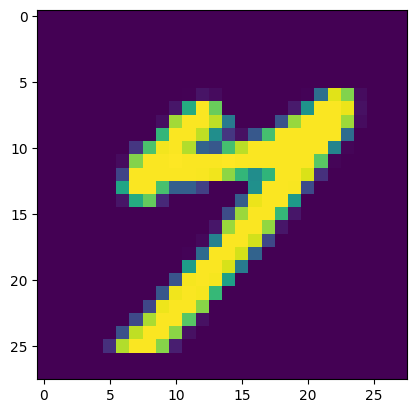

The image corresponding is : 7


In [4]:
# displaying a data point / image displaying


plt.imshow(x_train[1001])
plt.show()

# printing the corresponding ;abel

print(f"The image corresponding is : {y_train[1001]}")

In [5]:
# printing the unique values
print(np.unique(y_train))
print(np.unique(y_test))

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


Here the images are already resized if not we need to resixe the images using pil.resize()

In [6]:
# Now lets apply normalize to range of [0, 1] (not standardization)

x_train = x_train / 255
x_test = x_test / 255

In [7]:
print(x_train[1])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

In [9]:
# setting up the layers for the network

model = keras.Sequential(
    [
        keras.Input(shape=(28, 28)),
        keras.layers.Flatten(), # flatten the image to single dimension and give the size of image 28 * 28
        keras.layers.Dense(25, activation='relu'), # first layer of 25 neurons using Relu activation fucntion
        keras.layers.Dense(25, activation='relu'), # second layer of 25 neurons using Relu activation fucntion
        keras.layers.Dense(10, activation='sigmoid') # output must be the different classes [0, 1, 2, 3, ... 9]
            
        
        
    ]
)

print("The model is set!!")

The model is set!!


In [10]:
# compling the model

model.compile(
    optimizer = 'adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("The model is compiled!!")

The model is compiled!!


In [11]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 25)             │        19,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,535 (80.21 KB)

 Trainable params: 20,535 (80.21 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# training the model

history = model.fit(x_train, y_train, epochs=10 )


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8935 - loss: 0.3710
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9412 - loss: 0.1971
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9519 - loss: 0.1604
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9584 - loss: 0.1380
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9632 - loss: 0.1232
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9661 - loss: 0.1116
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9691 - loss: 0.1022
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9713 - loss: 0.0940
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9740 - loss: 0.0873
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9758 - loss: 0.0812


In [14]:
# training data accuracy is 97.82 % 

# accuracy of the training data


loss, accuracy = model.evaluate(x_test, y_test)

print(f"The accuracy : {accuracy * 100}%")
print(f"The loss : {loss * 100}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9623 - loss: 0.1301
The accuracy : 96.23000025749207%
The loss : 13.010446727275848%


In [15]:
y_pred = model.predict(x_test)
print(y_pred[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[9.0529871e-01 1.0035278e-04 2.4701957e-01 9.7922432e-01 5.4430616e-06
 2.9937400e-02 1.2303866e-08 9.9996263e-01 5.3969181e-01 7.9820655e-02]
